In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from qutip import rand_dm, ket2dm, tensor

In [14]:
# ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']

# Defining The Initial States
We define the $\rho_0$ and $\rho_1$ for the system. Here we use a 2 qubit system with dimension of 2, so that for N = 10, the system would be still scalable at dimention 1024 x 1024. Further higher dimensional system could be choosen, however is restricted because of hardware limitations.

In [15]:
rho0 = rand_dm(2, seed=809)
rho1 = rand_dm(2, seed=593)
print(rho0)
print(rho1)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.52757571+0.j         -0.4914341 +0.04660001j]
 [-0.4914341 -0.04660001j  0.47242429+0.j        ]]
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.42137976+0.j         0.10448641+0.25340495j]
 [0.10448641-0.25340495j 0.57862024+0.j        ]]


# Matrix Power Function
We define a matrix power function that return $\rho^t$ for any real t

In [16]:
def mat_power(rho, t):
    vals, vecs = rho.eigenstates()
    vals = np.maximum(vals, 0)
    return sum(v**t * ket2dm(vec) for v, vec in zip(vals, vecs))

# Defining $Q_s$
We define $Q_s$ as in the literature as $$Q_s = tr(\hat{\rho}_0^s \hat{\rho}_1^{1 - s})$$

In [17]:
def Qs(r0, r1, s):
    return np.real((mat_power(r0, s) * mat_power(r1, 1-s)).tr())

In [18]:
# Minimize Qs wrt s within the bounds 0 < s < 1
res = minimize_scalar(lambda s: Qs(rho0, rho1, s), bounds=(0.01,0.99), method='bounded')

In [19]:
# Extract the results
Q = res.fun
s_opt = res.x
Q_half = Qs(rho0, rho1, 0.5)
xi = -np.log(Q)
print(f"s*={s_opt:.4f}  Q={Q:.6f}  Q_half={Q_half:.6f}  xi={xi:.6f}")

s*=0.3800  Q=0.648201  Q_half=0.665716  xi=0.433554


In [20]:
def helstrom_N(r0, r1, N):
    r0N   = tensor([r0]*N)
    r1N   = tensor([r1]*N)
    Gamma = r1N - r0N
    evals = Gamma.eigenenergies()
    del r0N, r1N, Gamma
    return 0.5*(1.0 - 0.5*np.sum(np.abs(evals)))

In [21]:
N_max  = 10
N_vals = np.arange(1, N_max+1)
print("Computing Helstrom...")
PE_exact = np.array([helstrom_N(rho0, rho1, N) for N in N_vals])
print("Done:", PE_exact)

Computing Helstrom...
Done: [0.18016914 0.08001459 0.04034323 0.0248404  0.01777711 0.01038386
 0.00604171 0.00354992 0.00219609 0.00141352]


In [22]:
PE_QCB   = 0.5 * Q**N_vals
PE_bhat  = 0.5 * Q_half**N_vals
log_exact = np.log(np.maximum(PE_exact,1e-15)) / N_vals
log_QCB   = np.log(PE_QCB)  / N_vals
log_bhat  = np.log(PE_bhat) / N_vals

In [23]:
theta_vals = np.linspace(0,1,40)
pe_h,pe_q,pe_b,pe_f = [],[],[],[]
for th in theta_vals:
    r1t = th*rho1 + (1-th)*rho0
    ev  = (r1t-rho0).eigenenergies()
    pe_h.append(0.5*(1-0.5*np.sum(np.abs(ev))))
    res2 = minimize_scalar(lambda s,r=r1t: Qs(rho0,r,s),bounds=(0.01,0.99),method='bounded')
    pe_q.append(0.5*res2.fun)
    pe_b.append(0.5*Qs(rho0,r1t,0.5))
    r0h = mat_power(rho0,0.5)
    F   = float(np.real(((r0h*r1t*r0h).sqrtm()).tr()))
    pe_f.append((1-np.clip(F,0,1))/2)

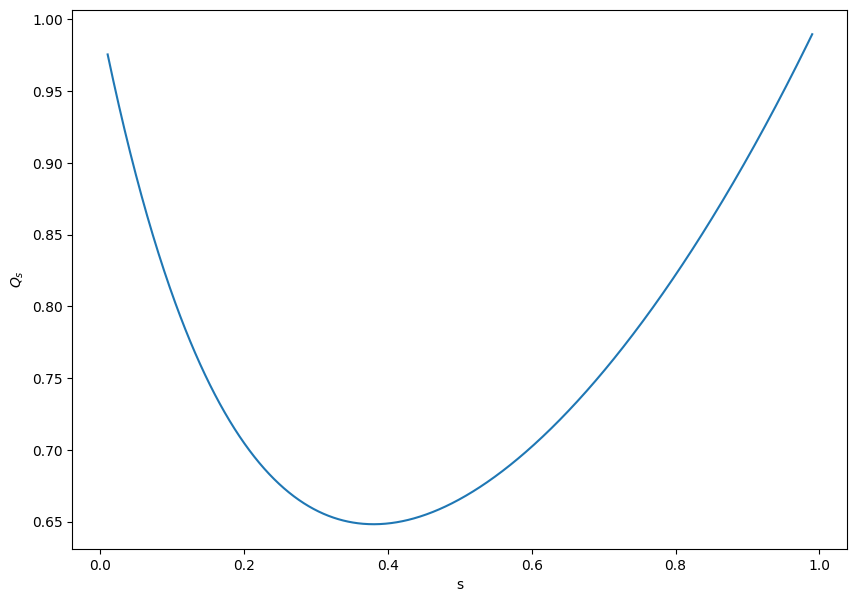

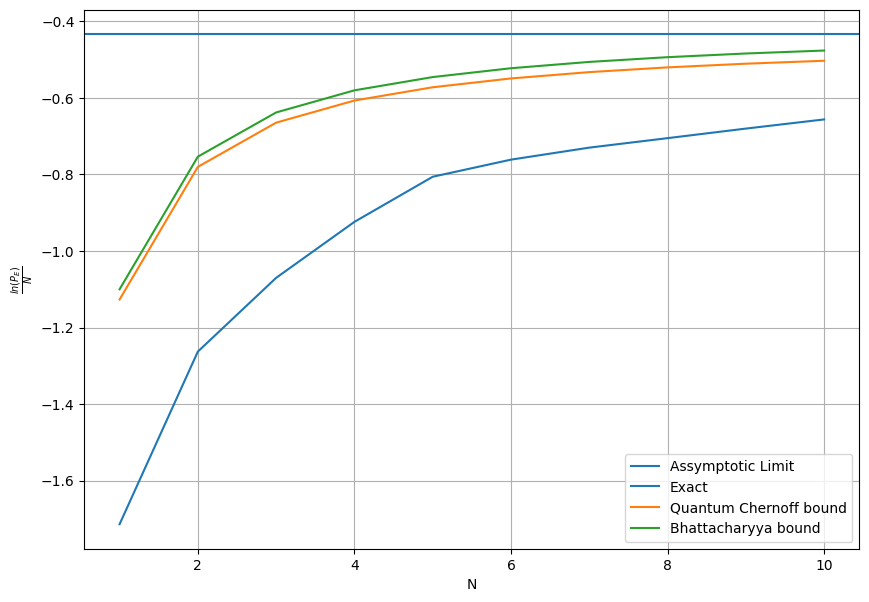

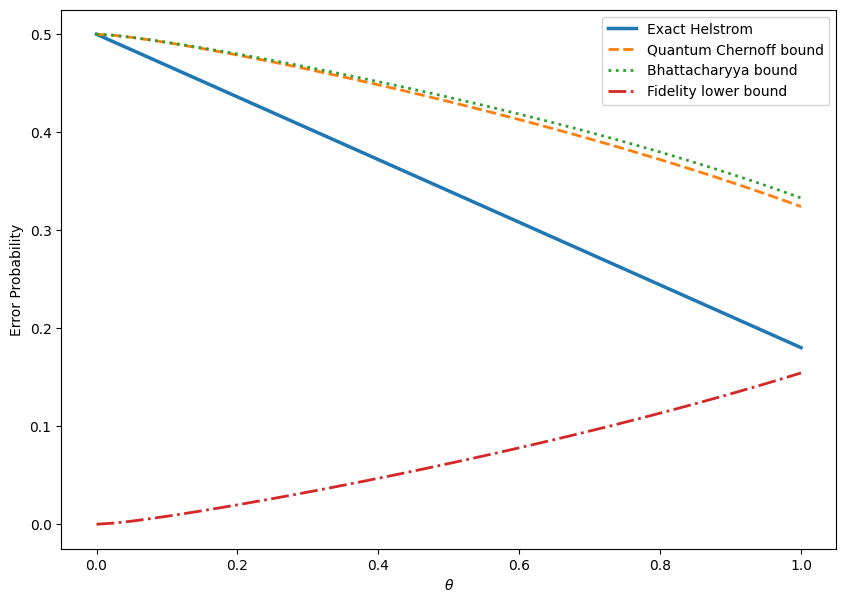

In [24]:
plt.figure(figsize=(10, 7))
s_values = np.linspace(0.01, 0.99, 1000)
Q_values = [Qs(rho0, rho1, s_) for s_ in s_values]
plt.plot(s_values, Q_values)
plt.xlabel('s')
plt.ylabel(R'$Q_s$')
plt.savefig('../figures/Q_vs_s.png', dpi=300)
plt.show()


plt.figure(figsize=(10, 7))
plt.axhline(-xi, label='Assymptotic Limit')
plt.plot(N_vals, log_exact, label='Exact')
plt.plot(N_vals, log_QCB, label='Quantum Chernoff bound')
plt.plot(N_vals, log_bhat, label='Bhattacharyya bound')
plt.xlabel('N')
plt.ylabel(R'$\frac{ln(P_E)}{N}$')
plt.grid()
plt.legend()
plt.savefig('../figures/QCB.png', dpi=300)
plt.show()


plt.figure(figsize=(10, 7))
plt.plot(theta_vals,pe_h,'-',lw=2.5,label='Exact Helstrom')
plt.plot(theta_vals,pe_q,'--',lw=2,  label='Quantum Chernoff bound')
plt.plot(theta_vals,pe_b,':',lw=2,  label='Bhattacharyya bound')
plt.plot(theta_vals,pe_f,'-.',lw=2,  label='Fidelity lower bound')
plt.xlabel(R'$\theta$')
plt.ylabel('Error Probability')
plt.legend()
plt.savefig('../figures/P_E.png', dpi=300)
plt.show()